LangGraph is a powerful library built on top of LangChain that focuses on creating stateful, multi-agent workflows using a graph structure. Let's start with the fundamental structure of LangGraph. We'll build a simple agent that just calls the LLM without any external tools. This helps understand the core concepts: State, Nodes, and Edges.

Key Components of LangGraph

- **StateGraph:** The core object for building workflows
- **Nodes:** Functions or agents that perform specific tasks
- **Edges:** Connections between nodes that control flow
- **State:** Information that persists across nodes
- **Conditional Routing:** Logic for determining which path to follow

In [3]:
# Install necessary libraries
# We need langchain, langgraph, openai integration, tavily, amadeus, and gradio
%pip install -q --upgrade langchain langgraph langchain_openai tavily-python amadeus python-dotenv gradio langchain_community graphviz
#tavily is used for searching the net, amadeus is used to find flights or hotels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Import necessary libraries
import os
import uuid
import getpass
from typing import TypedDict, Annotated, Sequence, List, Tuple, Optional, Any, Union, Literal,  Tuple
import operator
from datetime import date
from IPython.display import display, Markdown, Image
from graphviz import Source
import uuid  # Added for Gradio state

# Langchain specific imports
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool
from pydantic import BaseModel  # For tool args schema if needed explicitly
# LangGraph imports (Updated based on recent versions)
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode  # Preferred way to handle tool execution

# Gradio
import gradio as gr

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# Set environment variables (especially useful for LangChain integrations)
openai_api_key = os.environ["OPENAI_API_KEY"]

print("API Keys loaded (partially hidden for security):")
print(f"OpenAI Key starts with: {openai_api_key[:5]}...")


API Keys loaded (partially hidden for security):
OpenAI Key starts with: sk-pr...


In [ ]:
# Helper function to display markdown nicely
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))

In [6]:
#  define a simple workflow that includes a summarization function
#  define a state that includes two information: the original text and its summary
# State is how information persists and flows between nodes
# The state is like a container that stores and passes data between different parts of our workflow
# Each node receives and returns a state object, and the State can include messages, variables, memory, etc.

class AgentState(TypedDict):
    input_text:str
    summary:str
#our state here will be dictionary passed bw various nodes

In [9]:
# Let's define the key node, which represents the functions that perform specific tasks in your graph
# They receive the current state and return a modified state
# Note that a node can be simple functions, LLM calls, or complex agents
#remember, Nodes are functions

def summarize_step(state: AgentState) -> AgentState:  #node takes a state and returns a state
    """Create a concise sumary of the input text"""
    llm = ChatOpenAI(model="gpt-3.5-turbo")
    prompt = f"Please summarize the following text in one sentence that captures the main points: {state['input_text']}"

    #Get summary directly from model
    result = llm.invoke(prompt)

    #Update state with our summary
    return {
        "input_text": state["input_text"],
        "summary":result.content
    }

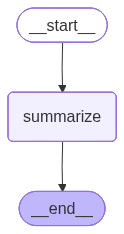

In [ ]:
#  define  StateGraph, which is the fundamental building block of LangGraph
# It manages the flow of information between different components
# It maintains state throughout the execution of your workflow

# Let's define a stategraph with the "AgentState" we defined earlier
workflow = StateGraph(AgentState)

# Let's add a node, which is the summarize function we defined before
workflow.add_node("summarize", summarize_step)

# Let's define Edges, which define how data flows between nodes
workflow.add_edge("summarize", END) 
workflow.set_entry_point("summarize") #entry point is the summarize step
workflow.compile() #compile the full thing

In [11]:
#  execute the graph 
# After defining your graph, you need to compile it to create an executable workflow
# Invoke it with an initial state to run the entire process

# Example text to summarize
sample_text = """
    Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """
    
# Let's compile the graph
graph = workflow.compile() 

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
        "summary": ""}
    
# Run the graph
result = graph.invoke(initial_state)
    
# Get the summary from the result
summary = result["summary"]
    
# Print the result
print(summary)

Electric cars use electricity stored in a battery pack to power an electric motor, providing efficient, emission-free transportation that can be recharged by plugging into an external power source and may also utilize regenerative braking to improve efficiency.


# BUILD AN AGENTIC WORKFLOW IN LANGGRAPH (SUMMARIZATION + TRANSLATION AGENT) WITH NO TOOLS

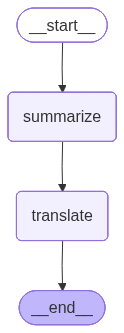

In [12]:
class AgentState(TypedDict):
    input_text:str
    summary:str
    translated_summary:str

def translate_step(state: AgentState)->AgentState:
    """Translate the summary"""

    llm = ChatOpenAI(model="gpt-3.5-turbo")
    prompt = f"Please translate the following summary into Spanish: {state['summary']}"

    result = llm.invoke(prompt)

    return{
        "input_text": state["input_text"],
        "summary": state["summary"],
        "translated_summary": result.content
    } 
    

#define the workflow
workflow = StateGraph(AgentState)
workflow.add_node("summarize", summarize_step)
workflow.add_edge("summarize", "translate")
workflow.add_node("translate", translate_step)
workflow.add_edge("translate", END)
workflow.set_entry_point("summarize")
workflow.compile()


In [ ]:
# Example text to summarize
sample_text = """
    Electric cars are awesome! I love them so much! They work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """
    
graph = workflow.compile()

initial_state = {
        "input_text": sample_text,
        "summary": "",
        "translated_summary": ""
    }
#run graph
result = graph.invoke(initial_state)

# Get the summary from the result, note we r returning dictionaries, as stat is a dict which persists throughout the graph
summary = result["summary"]
translation = result["translated_summary"]

# Print the results with clear labels and spacing
print("=== Generated Summary ===")
print(summary)

print("\n=== Translated Summary ===")
print(translation)

=== Generated Summary ===
Electric cars use electricity stored in a battery pack to power an electric motor, offering more efficiency and zero emissions compared to gasoline-powered vehicles, with the ability to recharge the battery by plugging the car into an external power source and potential for regenerative braking to improve efficiency.

=== Translated Summary ===
Los coches eléctricos utilizan la electricidad almacenada en una batería para alimentar un motor eléctrico, ofreciendo mayor eficiencia y cero emisiones en comparación con los vehículos de gasolina, con la capacidad de recargar la batería enchufando el coche a una fuente de energía externa y el potencial de frenado regenerativo para mejorar la eficiencia.


# LANGGRAPH WITH SINGLE TOOL (WEB SEARCH) USING TOOLNODE & CONDITIONAL EDGE


Now, let's give our agent its first superpower: the ability to search the web using the Tavily tool. We'll `ToolNode` for handling tool execution.

**Changes:**

1.  **Tool Definition:** Define the `tavily_search_tool`.
2.  **Nodes:**
    *   Define `call_model_with_tools` node that binds the tool(s) to the LLM.
    *   Instantiate `ToolNode`: Create an instance of `ToolNode` with our list of tools.
3.  **Conditional Edge:** Use the `should_continue` function (which checks the last message for tool calls) to direct the flow.
4.  **Graph Construction:**
    *   Add the `call_model_with_tools` node ("agent").
    *   Add the instantiated `ToolNode` as the "action" node.
    *   Set the entry point to "agent".
    *   Add the conditional edge from "agent" based on `should_continue` to either "action" or `END`.
    *   Add a direct edge from "action" back to "agent".

So basically, what we do over here is, initially what we do is we redefine the, we bind the tool, that is a predefined tool, that is a Tevaly search tool, to our LLM. And after binding it, we set a conditional edge. Okay, what we're gonna do is we're gonna set a conditional edge wherein if required, then we can instantiate that tool, meaning, make a call to that tool, use that tool. Okay, for example, Tevaly search tool, we can search the web with our LLM. Okay, and that is how the two nodes are there that is going to be defined earlier, as mentioned in the markdown.


In [18]:
from dotenv import load_dotenv
load_dotenv()
tavily_api_key = os.environ["TAVILY_API_KEY"]
print(f"Tavily Key starts with: {tavily_api_key[:5]}...")

Tavily Key starts with: tvly-...


In [19]:
# Define the Agent State
class AgentState(TypedDict):
    # AgentState is the name of the dictionary (used to represent the agent's state in the workflow).
    # It has one key: "messages", which holds a list of messages (e.g., from the user, model, or tools).
    # BaseMessage is the type used to represent each message in that list.
    # operator.add tells LangGraph to append new messages to the list during execution.
    messages: Annotated[Sequence[BaseMessage], operator.add]

#basically we r doin this annotated way to append the messages by the llm , or the functions, or by tavily everytime, so we can see what work is being done

In [21]:
#Let's set up our search tool that fetches results from Tavily (a search engine wrapper)
# Setting max_results to 3 limits the number of search results.

from langchain_community.tools.tavily_search import TavilySearchResults

tavily_search_tool = TavilySearchResults(max_results = 3)

# List of tools for this step
tools_list_single = [tavily_search_tool]

C:\Users\Cleaven Dcosta\AppData\Local\Temp\ipykernel_4516\3944541145.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(max_results = 3)


In [ ]:
#  define call_model_with_tools node that binds the tool(s) to the LLM.
# This format is useful when you want to reuse the same model logic with different tools.
# You're building modular, reusable parts for your AI workflow (like LangGraph nodes).
# The Outer function (make_call_model_with_tools(tools)):
# It knows about the tools and returns a customized inner function.

# Inner function (call_model_with_tools(state)): This is the execution function. 
# It knows how to use the current state (conversation history) and actually runs the model with the tools that were set up by the outer function.

def make_call_model_with_tools(tools: list):   #set tool list to bind to llm
    def call_model_with_tools(state: AgentState): #llm
            print("DEBUG: Entering call_model_with_tools node")
            messages = state["messages"]

            #Binds tools to language model
            model_with_tools = llm.bind_tools(tools)    

            #Feeds convo history(messages) into the model
            response = model_with_tools.invoke(messages)

            #return the model response as a new message
            return {
                  "messages": [messages]
            }
    return call_model_with_tools 

In [ ]:
# Define Conditional Edge Logic
# This function checks the most recent message in the state and decides whether to route to the 'action' node (ToolNode) or end.
# This function is used to control the flow of your agent, it's like a traffic signal deciding where to send the agent next.
# The function should_continue checks the last message in the agent's memory and decides:
# If the message includes a tool call, it routes to the next step (the action node, where the tool is actually used).
# If there's no tool call, it ends the conversation (__end__).

def should_continue(state: AgentState)->Literal["action", "__end__"]:
    """Determines the next step: continue with tools or not"""
    print("DEBUG: Entering should_continue node")
    last_message = state["messages"][-1] #we check the last message, if it involves any word regarding tools, then we go to the action step else end

    #Check if last message is an AIMessage weith tool calls
    if isinstance(last_message, AIMessage) and hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("DEBUG: Decision: continue (route to action)")
        return "action"  # Route to the node named "action"
    else:
        print("DEBUG: Decision: end (route to END)")
        return END  # Special value indicating the end of the graph


In [ ]:
# ToolNode is a prebuilt ready-to-use node from LangGraph that is specifically designed to run external tools 
# like search, calculator, database query
#we will use it here to run the tool of tailvy to search the web

def build_graph_one_tool(tools_list):

    #Instantiate Tool Node
    tool_node = ToolNode(tools_list)

    #Bind the toolnode to the LLM thru the function call
    call_node_fn =make_call_model_with_tools(tools_list)

    #Build the graph
    graph_one_tool = StateGraph(AgentState)

    graph_one_tool.add_node("agent", call_node_fn)
    graph_one_tool.add_node("action", tool_node)
    graph_one_tool.set_entry_point("agent")

     # Add a conditional edge from the agent
    # The dictionary maps the return value of 'should_continue' ("action" or END)
    # to the name of the next node ("action" or the special END value).
    graph_one_tool.add_conditional_edges(
        "agent", #source node
        should_continue, #function to decide the route
        {"action": "action", END: END} # Mapping: {"decision": "destination_node_name"}
    )
    #add node from the action back to the agent
    graph_one_tool.add_node("action", "agent")

    #Compile the grapg
    app = graph_one_tool.compile()

    #Visualize
    display(Image(app.get_graph().draw_mermaid_png()))
  
    return app


In [ ]:
#Main function to perform operation
def app_call(app, messages):
    # Initialize the state with the provided messages
    initial_state = {"messages": [HumanMessage(content=messages)]}

    # Invoke the app with the initial state
    final_state = app.invoke(initial_state)

    # Iterate through the messages in the final state
    for i in final_state["messages"]:
        # Print the type of the message in markdown format
        print_markdown(i.type)
        # Print the content of the message in markdown format
        print_markdown(i.content)
        # Print any additional kwargs associated with the message
        if i.additional_kwargs != {}:
            print(i.additional_kwargs)

    # Return the content of the last message and the final state
    return final_state["messages"][-1].content, final_state

In [ ]:
app = build_graph_one_tool(tools_list_single)

In [ ]:
messages = "What's the latest news on France in May 2025? Is it a good time to visit?"
output, history = app_call(app, messages)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

# TASK 6: CREATE AND ADD A CUSTOM NEW TOOL

**Goal:** Show how to wrap any Python function as a LangChain tool so it can be automatically discovered and invoked by your agent.

In [ ]:
@tool
def get_current_date_tool():
    """Returns the current date in YYY-MM-DD format. Used to get dates for hotel or flight booking"""
    return date.today().isoformat()

app_current_date = build_graph_one_tool([get_current_date_tool])

#prepare input
prompt = "What is todays date"
output, history = app_call(app_current_date,  prompt)

# LEVERAGE LANGGRAPH TO PERFORM FLIGHT SEARCH USING AMADEUS & `ToolNode`

In [ ]:
# Load environment variables
from dotenv import load_dotenv
load_dotenv()

amadeus_api_key = os.environ["AMADEUS_CLIENT_ID"]
amadeus_api_secret = os.environ["AMADEUS_CLIENT_SECRET"]
print(f"Amadeus Key starts with: {amadeus_api_key[:5]}...")
print(f"Amadeus Secret starts with: {amadeus_api_secret[:5]}...")

In [ ]:
# Service clients
from amadeus import Client, ResponseError

# Configure Amadeus Client
# We'll only initialize it if keys are provided, inside the tool later
amadeus_client = Client(
    client_id = amadeus_api_key,
    client_secret = amadeus_api_secret,
    hostname = "test",  # Start with the test environment
)


In [ ]:
@tool
def search_flights_tool(
    origin_code: str,
    destination_code: str,
    departure_date: str,
    return_date: str | None = None,
    adults: int = 1,
    travel_class: str = "ECONOMY",
    currency: str = "USD",
    max_offers: int = 5,
):
    """
    Searches live flight prices and availability via Amadeus Flight Offers Search API.
    Required:
        origin_code, destination_code – IATA airport/city codes (e.g., 'YYZ', 'LHR')
        departure_date – 'YYYY-MM-DD'
    Optional:
        return_date – for round‑trips; omit for one‑way
        adults – number of adult passengers (default 1)
        travel_class – 'ECONOMY', 'PREMIUM_ECONOMY', 'BUSINESS', 'FIRST'
        currency – 3‑letter code for pricing (default USD)
        max_offers – how many offers to list back
    """

    print(
        f"DEBUG: Calling Amadeus Flight Search – "
        f"{origin_code}->{destination_code}, "
        f"Depart {departure_date}, Return {return_date}, "
        f"Adults {adults}, Class {travel_class}"
    )

    # --- Call Amadeus Flight Offers Search API ---
    flight_search_params = {
        "originLocationCode": origin_code,
        "destinationLocationCode": destination_code,
        "departureDate": departure_date,
        "adults": adults,
        "travelClass": travel_class,
        "currencyCode": currency,
        "max": max_offers,
    }
    if return_date:
        flight_search_params["returnDate"] = return_date

    response = amadeus_client.shopping.flight_offers_search.get(**flight_search_params)

    # --- Parse the response ---
    if not response.data:
        return (
            f"No flight offers found for {origin_code} → {destination_code} on "
            f"{departure_date}{' (return '+return_date+')' if return_date else ''}."
        )

    results = []
    for offer in response.data[:max_offers]:
        price = offer["price"]["total"]
        airline = offer["validatingAirlineCodes"][0]
        itinerary = offer["itineraries"][0]
        segments = itinerary["segments"]
        first_leg = segments[0]
        last_leg = segments[-1]
        dep_time = first_leg["departure"]["at"][:16].replace("T", " ")
        arr_time = last_leg["arrival"]["at"][:16].replace("T", " ")
        duration = itinerary["duration"].replace("PT", "")
        results.append(f"{airline} | {dep_time} → {arr_time} | {duration} | {price} {currency}")

    return "Found flight options:\n- " + "\n- ".join(results)


# Create Flight SearchTools List
tools_list_full = [
    get_current_date_tool,
    search_flights_tool,
]

app_flight_search = build_graph_one_tool(tools_list_full)

In [ ]:
# Prepare your input
prompt = "I want to go to Paris from Toronto for the first week of June. Can you find flight options for 2 adults?"
output, history = app_call(app_flight_search, prompt)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

In [ ]:
tools = [
    tavily_search_tool,
    search_flights_tool,
    get_current_date_tool,
]

app_travel_agent = build_graph_one_tool(tools)

# Prepare your input
prompt = "I want the latest news about New York, I'm planning to visit from 2025-06-01 to 2025-06-04, leaving from Toronto. Please fetch security and travel advisories, find the cheapest flight for one adult. Finally, format the combined output."
output, history = app_call(app_travel_agent, prompt)

In [ ]:
print_markdown(output)